In [32]:
import Layers
import asyncio
import io
import time
from typing import Dict
from PIL import Image, ImageChops, ImageEnhance
import numpy as np
import pickle
import matplotlib.pyplot as plt

Add bias https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/tree/main


In [33]:
with open('model', 'rb') as f:
    model = pickle.load(f)
with open('__results___9_0.png', 'rb') as f:
    img = np.asarray(Image.open(f))

In [34]:
def convert_to_ela_image(path, quality):
    temp_filename = 'temp_file_name.jpg'
    ela_filename = 'temp_ela.png'
    
    image = Image.open(path).convert('RGB')
    return image
    image.save(temp_filename, 'JPEG', quality = quality)
    temp_image = Image.open(temp_filename)
#     return temp_image
    
    ela_image = ImageChops.difference(image, temp_image)
    
    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    
    return ela_image

def prepare_image(image_path):
    image_size = (128, 128)
    return np.array(convert_to_ela_image(image_path, 90).resize(image_size)) / 255.0
test_images = ['__results___9_0.png', '168214430415469965.png', 'FwFGFkJWYAEykWm.jpg', 'F0Hvu0aXgAA0UsH.jpg']
p_img = prepare_image(test_images[0])

In [35]:
model(p_img)

array([[0.54356146, 0.45643854]])

In [36]:
pred, res = model.lrp(p_img)

(1, 48, 48, 8)
(800, 8)
(1, 52, 52, 32)
(800, 32)
(1, 56, 56, 32)
(800, 32)
(1, 120, 120, 32)
(800, 32)


In [37]:
pred

0.5435614632389055

In [38]:
model.layers[1:][::-1]

In [39]:
model.layers

In [40]:
mock_res = np.array([[1, 0]])
for l in model.layers[:-7:-1]:
    mock_res = l.lrp_backward(mock_res)

In [41]:
lrp_res = []
r1 = np.array([[1, 0]])
for l in model.layers[1:][::-1]:
    r1 = l.lrp_backward(r1)
    lrp_res.append(r1)

(1, 48, 48, 8)
(800, 8)
(1, 52, 52, 32)
(800, 32)
(1, 56, 56, 32)
(800, 32)
(1, 120, 120, 32)
(800, 32)


In [42]:
mock_res.shape

(1, 48, 48, 8)

In [43]:
def stan(img):
    return (img-img.min())/(img.max()-img.min())

In [44]:
res[0]

array([[[ 5.74898940e-07,  0.00000000e+00,  9.31342784e-08, ...,
          1.94844194e-07, -7.96458978e-07,  9.64189822e-08],
        [ 5.77296653e-07,  0.00000000e+00,  8.97107426e-08, ...,
          1.94047918e-07, -7.93961418e-07,  9.73195722e-08],
        [ 6.04393467e-07,  0.00000000e+00,  9.03072756e-08, ...,
          2.02689924e-07, -8.22303987e-07,  9.83560145e-08],
        ...,
        [-3.58906785e-07,  0.00000000e+00,  9.65048834e-08, ...,
          1.72952198e-07, -3.27994777e-07,  7.30960291e-08],
        [ 4.04127873e-07,  0.00000000e+00, -1.46774758e-08, ...,
          2.08350531e-07, -4.84447766e-07,  1.47422803e-08],
        [ 2.39743596e-07, -0.00000000e+00,  4.42356900e-08, ...,
         -1.53900779e-07,  6.77092704e-07,  3.35935420e-07]],

       [[ 5.80561421e-07,  0.00000000e+00,  8.83850814e-08, ...,
          1.98457760e-07, -7.97919567e-07,  9.69672117e-08],
        [ 5.80044666e-07,  0.00000000e+00,  8.76458162e-08, ...,
          2.00401022e-07, -7.97635636e

In [45]:
mock_res[0,-7:,-7:,0]

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-0.,  0.,  0.,  0.,  0., -0., -0.],
       [-0.,  0.,  0.,  0.,  0., -0., -0.],
       [ 0., -0., -0.,  0.,  0., -0., -0.],
       [ 0., -0., -0.,  0.,  0., -0., -0.],
       [-0., -0., -0., -0., -0.,  0.,  0.],
       [-0., -0., -0., -0., -0.,  0.,  0.]])

In [46]:
for ix, x in enumerate(lrp_res):
    print(ix, x.shape)

0 (1, 2)
1 (1, 256)
2 (1, 256)
3 (1, 4608)
4 (1, 24, 24, 8)
5 (1, 48, 48, 8)
6 (1, 48, 48, 8)
7 (1, 52, 52, 32)
8 (1, 52, 52, 32)
9 (1, 56, 56, 32)
10 (1, 56, 56, 32)
11 (1, 60, 60, 32)
12 (1, 120, 120, 32)
13 (1, 120, 120, 32)
14 (1, 124, 124, 32)
15 (1, 124, 124, 32)


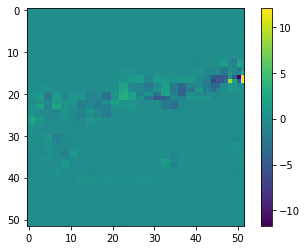

In [47]:
plt.imshow(lrp_res[8][0,:,:].sum(-1))
plt.colorbar()

In [48]:
# res[1].shape

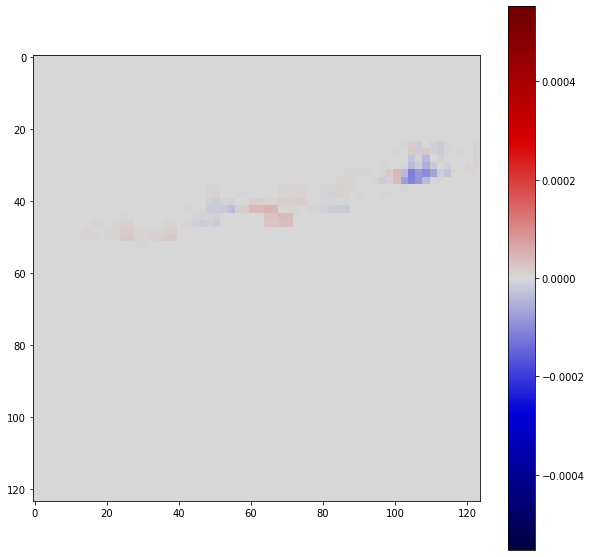

In [49]:
plt.figure(figsize = (10,10))
b = 10*((np.abs(res)**3.0).mean()**(1.0/3))

from matplotlib.colors import ListedColormap
my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
my_cmap[:,0:3] *= 0.85
my_cmap = ListedColormap(my_cmap)
plt.imshow(res.mean(-1)[0],cmap=my_cmap,vmin=-b,vmax=b,interpolation='nearest')


# plt.imshow(stan(res[0].sum(-1)))
plt.colorbar()

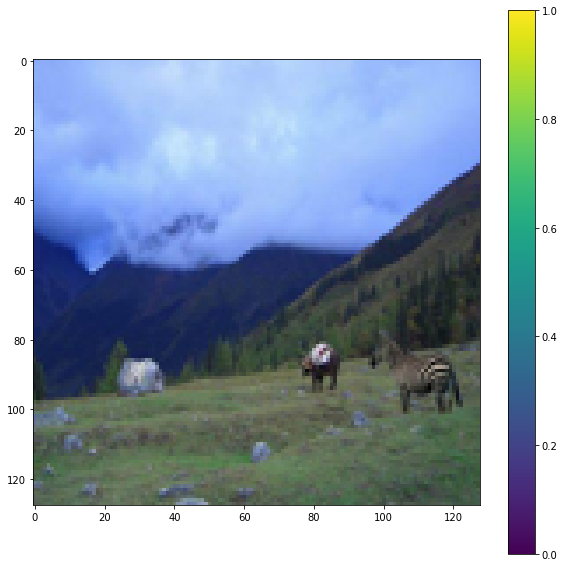

In [50]:
plt.figure(figsize = (10,10))
plt.imshow(stan(p_img))
plt.colorbar()

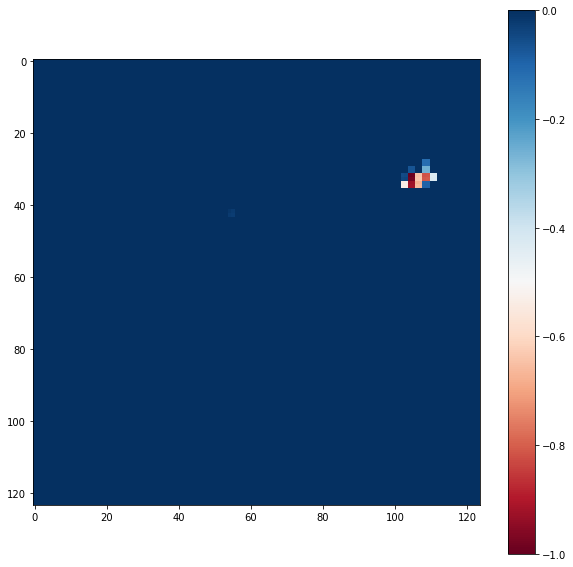

In [51]:
plt.figure(figsize = (10,10))
x = p_img[2:-2,2:-2:] * ((res.reshape(124,124,32)-res.min())/(res.max()-res.min())).mean(-1).reshape(124,124,-1)
rn = stan(res.reshape(124,124,32).sum(-1)) * 2 -1
filt = 0
rn[(rn<=(1-filt)) & (rn>=-filt)] = 0
plt.imshow(rn, cmap = 'RdBu')
plt.colorbar()

In [52]:
h,w,c = 128,128,32
np.unique(np.arange(h*w*c).reshape(1,h,w,c),axis = 0).shape

(1, 128, 128, 32)

In [53]:
model.layers[2].img_inds.max()

492031

In [54]:
model.layers[2].output_shape

(-1, 120, 120, 32)